In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegressionCV, LassoCV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, classification_report

from utils.data_loader import load_data

# Loading data

In [2]:
final_clean_strained = load_data(db_level=0)

In [3]:
peak_curvs = final_clean_strained["PeakI Curvature"].apply(pd.Series)
peak_curvs.columns = [
    "PeakI Left Curvature",
    "PeakI Overall Curvature",
    "PeakI Right Curvature",
]
trough_curvs = final_clean_strained["TroughI Curvature"].apply(pd.Series)
trough_curvs.columns = [
    "TroughI Left Curvature",
    "TroughI Overall Curvature",
    "TroughI Right Curvature",
]
final_clean_strained = pd.concat(
    [final_clean_strained, peak_curvs, trough_curvs], axis=1
)

In [4]:
final_clean_strained

,Subject,Frequency(kHz),Level(dB),Amplitude,vx,SynapsesPerIHC,IHCs,OrphansPerIHC,Waveform,WaveI,...,Noise,Time (str),Time (hrs),Strain (binary),PeakI Left Curvature,PeakI Overall Curvature,PeakI Right Curvature,TroughI Left Curvature,TroughI Overall Curvature,TroughI Right Curvature
0,WPZ145,45.2,70.0,0.065036,v1,8.750000,8.8,1.136364,0 -0.112169 1 -0.113246 2 -0.12227...,24 0.085347 25 0.052718 26 0.054619 2...,...,0.98,8wks,56.0,1,8.728268,17.963543,5.970192,14.853267,4.864488,11.907941
0,WPZ145,45.2,70.0,0.065036,v2,10.888889,9,1.222222,0 -0.112169 1 -0.113246 2 -0.12227...,24 0.085347 25 0.052718 26 0.054619 2...,...,0.98,8wks,56.0,1,8.728268,17.963543,5.970192,14.853267,4.864488,11.907941
1,WPZ145,45.2,75.0,0.034276,v1,8.750000,8.8,1.136364,0 -0.111887 1 -0.099311 2 -0.07184...,31 -0.177462 32 -0.163745 33 -0.166343 3...,...,0.98,8wks,56.0,1,19.722385,17.625119,41.094585,56.515570,21.375630,19.580860
1,WPZ145,45.2,75.0,0.034276,v2,10.888889,9,1.222222,0 -0.111887 1 -0.099311 2 -0.07184...,31 -0.177462 32 -0.163745 33 -0.166343 3...,...,0.98,8wks,56.0,1,19.722385,17.625119,41.094585,56.515570,21.375630,19.580860
2,WPZ145,45.2,80.0,0.153990,v1,8.750000,8.8,1.136364,0 -0.021953 1 -0.030063 2 -0.01473...,44 0.052491 45 0.061552 46 0.070517 4...,...,0.98,8wks,56.0,1,26.976632,21.494901,11.888853,35.536270,7.732720,1.009957
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7328,WPZ101,32.0,60.0,1.635883,v2,15.463918,9.7,0.000000,0 -0.048551 1 -0.010029 2 -0.02498...,23 0.206272 24 0.204751 25 0.213115 2...,...,0.00,8wks,56.0,1,1.066475,74.041299,0.702918,1.488338,22.622224,22.945029
7329,WPZ101,32.0,70.0,1.771467,v1,16.923077,9.1,0.000000,0 -0.027782 1 -0.022587 2 -0.06326...,22 -0.028416 23 -0.037919 24 0.001109 2...,...,0.00,8wks,56.0,1,0.750480,19.779132,0.049144,1.881433,67.759450,4.235397
7329,WPZ101,32.0,70.0,1.771467,v2,15.463918,9.7,0.000000,0 -0.027782 1 -0.022587 2 -0.06326...,22 -0.028416 23 -0.037919 24 0.001109 2...,...,0.00,8wks,56.0,1,0.750480,19.779132,0.049144,1.881433,67.759450,4.235397
7330,WPZ101,32.0,80.0,1.879935,v1,16.923077,9.1,0.000000,0 -0.036950 1 -0.055197 2 -0.07344...,21 0.052257 22 0.112573 23 0.155149 2...,...,0.00,8wks,56.0,1,1.030210,52.126847,0.045458,0.034189,55.368839,81.235287


In [49]:
final_clean_strained = final_clean_strained[final_clean_strained["Level(dB)"] % 2 == 0]

In [50]:
def split_by_mouse(
    data,
    split_on="Subject",
    stratify_on="Group",
    test_size=0.2,
    val_size=0.18,
    random_state=22,
    return_idx=False,
):
    mice = data[[split_on, stratify_on]].drop_duplicates().set_index(split_on)

    train, test = train_test_split(
        mice.index,
        test_size=test_size,
        shuffle=True,
        stratify=mice[stratify_on],
        random_state=random_state,
    )

    train_indices = data[split_on].isin(train)
    test_indices = data[split_on].isin(test)

    train2, val = train_test_split(
        train,
        test_size=val_size,
        shuffle=True,
        stratify=mice.loc[train]["Group"],
        random_state=random_state,
    )

    train2_indices = data[split_on].isin(train2)
    val_indices = data[split_on].isin(val)

    data["DataGroup"] = ""
    data.loc[train2_indices, "DataGroup"] = "Train"
    data.loc[val_indices, "DataGroup"] = "Validate"
    data.loc[test_indices, "DataGroup"] = "Test"
    if return_idx:
        return data, train_indices, train2_indices, val_indices, test_indices
    return data

# Train test split

In [51]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    FunctionTransformer,
    MinMaxScaler,
)


def RF_data_prep(
    data,
    num_features,
    cat_features,
    log_features,
    minmax_features,
    target="SynapsesPerIHC",
):
    X = data[num_features + cat_features + log_features + minmax_features]
    y = data[target]

    X_train, X_test, y_train, y_test = (
        X[data.DataGroup != "Test"],
        X[data.DataGroup == "Test"],
        y[data.DataGroup != "Test"],
        y[data.DataGroup == "Test"],
    )

    log_scale_pipeline = Pipeline(
        [
            ("log_transform", FunctionTransformer(np.log1p, validate=True)),
            ("scaler", StandardScaler()),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), num_features),
            ("cat", OneHotEncoder(drop="first", sparse_output=False), cat_features),
            ("log_transform", log_scale_pipeline, log_features),
            ("minmax_scale", MinMaxScaler(), minmax_features),
        ]
    )

    return X_train, X_test, y_train, y_test, preprocessor

In [52]:
final_clean_strained = split_by_mouse(final_clean_strained)
num_features = ["Amplitude", "Slope", "Distance", "Level(dB)"]
cat_features = ["vx", "Strain (binary)"]
log_features = [
    "Frequency(kHz)",
    "Total Variance",
    "PeakI Left Curvature",
    "PeakI Overall Curvature",
    "PeakI Right Curvature",
    "TroughI Left Curvature",
    "TroughI Overall Curvature",
    "TroughI Right Curvature",
]
minmax_features = ["Noise", "Time (hrs)"]
X_train, X_test, y_train, y_test, preprocessor = RF_data_prep(
    final_clean_strained, num_features, cat_features, log_features, minmax_features
)

In [53]:
final_clean_strained.columns = [
    "Subject",
    "Frequency(kHz)",
    "Level",
    "Amplitude",
    "vx",
    "SynapsesPerIHC",
    "IHCs",
    "OrphansPerIHC",
    "Waveform",
    "WaveI",
    "Peaks",
    "Troughs",
    "Slope",
    "TotalVariance",
    "Distance",
    "PeakICurvature",
    "TroughICurvature",
    "Strain",
    "Sex",
    "Group",
    "Noise",
    "Time(str)",
    "Time_hrs",
    "Strain_b",
    "PeakILeftCurvature",
    "PeakIOverallCurvature",
    "PeakIRightCurvature",
    "TroughILeftCurvature",
    "TroughIOverallCurvature",
    "TroughIRightCurvature",
    "DataGroup",
]

In [54]:
cols = [
    "Amplitude",
    "Slope",
    "Distance",
    "TotalVariance",
    "PeakILeftCurvature",
    "PeakIOverallCurvature",
    "PeakIRightCurvature",
    "TroughILeftCurvature",
    "TroughIOverallCurvature",
    "TroughIRightCurvature",
]

reformatted = []

for col in cols:
    df = (
        final_clean_strained.pivot_table(
            index=["Subject", "Frequency(kHz)"], columns="Level", values=col
        )
        .rename_axis(columns="Level_dB")
        .add_prefix(f"{col}_")
    )
    reformatted.append(df)
reformatted = pd.concat(reformatted, axis=1)

# Add Noise column
noise = final_clean_strained.groupby(["Subject", "Frequency(kHz)"])["Noise"].mean()
synapses = final_clean_strained.groupby(["Subject", "Frequency(kHz)"])[
    "SynapsesPerIHC"
].mean()
groups = final_clean_strained.groupby(["Subject", "Frequency(kHz)"])[
    ["DataGroup", "Strain_b"]
].first()

# Combine
reformatted = reformatted.join(noise).join(synapses).join(groups)

# fill NaNs with interpolated/extrapolated values:
for col in cols:
    amp_cols = [c for c in reformatted.columns if c.startswith(col)]
    reformatted[amp_cols] = reformatted[amp_cols].interpolate(
        axis=1, limit_direction="both"
    )
reformatted.reset_index(inplace=True)
reformatted.head(10)

,Subject,Frequency(kHz),Amplitude_10.0,Amplitude_20.0,Amplitude_30.0,Amplitude_40.0,Amplitude_50.0,Amplitude_60.0,Amplitude_70.0,Amplitude_80.0,...,TroughIRightCurvature_30.0,TroughIRightCurvature_40.0,TroughIRightCurvature_50.0,TroughIRightCurvature_60.0,TroughIRightCurvature_70.0,TroughIRightCurvature_80.0,Noise,SynapsesPerIHC,DataGroup,Strain_b
0,WPZ100,8.0,0.029777,0.029777,0.137358,0.381854,0.657141,0.889789,1.027781,1.632715,...,15.628663,3.435267,4.514280,25.079451,2.706432,0.773064,0.00,15.892142,Test,1
1,WPZ100,11.3,0.000000,0.000000,0.302752,0.477460,0.860391,1.053503,1.480784,2.005255,...,2.921424,24.221959,7.466661,5.094698,0.211666,0.310118,0.00,16.492360,Test,1
2,WPZ100,16.0,0.059556,0.047106,0.202553,0.424367,0.628123,1.043303,1.692017,2.395915,...,5.836390,32.029460,5.866059,0.390464,0.510088,0.157028,0.00,17.564103,Test,1
3,WPZ100,22.6,0.060886,0.060886,0.223176,0.359520,0.731459,1.038678,1.577594,2.235242,...,29.150169,18.049232,5.496520,1.643706,0.080963,0.800270,0.00,17.381424,Test,1
4,WPZ100,32.0,0.257800,0.257800,0.333101,0.664046,1.018594,1.442390,1.773242,2.316719,...,1.554330,0.059375,1.020433,0.622318,4.409113,0.100350,0.00,18.314239,Test,1
5,WPZ100,45.2,0.064308,0.064308,0.054423,0.151740,0.375233,0.772641,0.833908,0.973166,...,6.903067,36.977904,0.608373,12.019363,0.808162,0.325440,0.00,17.846405,Test,1
6,WPZ101,32.0,0.054107,0.057180,0.411283,0.734120,1.423003,1.635883,1.771467,1.879935,...,6.228837,3.065256,0.556963,22.945029,4.235397,81.235287,0.00,16.193497,Train,1
7,WPZ101,45.2,0.043558,0.131910,0.140146,0.097000,0.127538,0.061995,0.078975,0.335033,...,21.569207,6.057603,8.195234,4.778665,6.866563,8.283850,0.00,15.351421,Train,1
8,WPZ102,8.0,0.067254,0.126208,0.139418,0.441124,0.708587,0.803876,1.378526,1.821139,...,0.006334,2.409508,4.888168,3.181216,26.503023,0.647380,0.94,14.334043,Train,1
9,WPZ102,11.3,0.195773,0.095163,0.310324,0.693951,0.762503,1.098107,1.513350,2.552028,...,2.501294,4.134924,4.024901,2.266414,0.140623,0.054206,0.94,16.569307,Train,1


# Predicting Binary Noise Groups (<91dB vs. >= 91dB)

In [55]:
reformatted["Noise"].value_counts()

Noise
0.00    193
0.90    100
0.98     99
0.94     91
0.98     48
0.94     43
0.94     16
1.01     16
0.98     10
Name: count, dtype: int64

In [56]:
num_features = []
cat_features = []
log_features = ["Frequency(kHz)"]
for col in [
    "TotalVariance",
    "PeakILeftCurvature",
    "PeakIOverallCurvature",
    "PeakIRightCurvature",
    "TroughILeftCurvature",
    "TroughIOverallCurvature",
    "TroughIRightCurvature",
]:
    cols = [c for c in reformatted.columns if c.startswith(col)]
    log_features.extend(cols)

for col in ["Amplitude", "Slope", "Distance"]:
    cols = [c for c in reformatted.columns if c.startswith(col)]
    num_features.extend(cols)

reformatted["target_90"] = [0 if x else 1 for x in (reformatted["Noise"] <= 0.91)]
X = reformatted[num_features + cat_features + log_features]
y = reformatted["target_90"]

X_train, X_test, y_train, y_test = (
    X[reformatted.DataGroup != "Test"],
    X[reformatted.DataGroup == "Test"],
    y[reformatted.DataGroup != "Test"],
    y[reformatted.DataGroup == "Test"],
)

log_scale_pipeline = Pipeline(
    [
        ("log_transform", FunctionTransformer(np.log1p, validate=True)),
        ("scaler", StandardScaler()),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(drop="first", sparse_output=False), cat_features),
        ("log_transform", log_scale_pipeline, log_features),
    ]
)

In [57]:
pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("elasticnet_cv", LogisticRegressionCV(l1_ratios=(0,), cv=5)),
    ]
)
pipeline.fit(X_train, y_train)
print(f"Logistic regression training set accuracy: {pipeline.score(X_train, y_train)}")
print(f"Logistic regression test set accuracy: {pipeline.score(X_test, y_test)}")

Logistic regression training set accuracy: 0.7128309572301426
Logistic regression test set accuracy: 0.68


In [58]:
rf_params = {
    "rf__n_estimators": [25, 50, 100, 150, 200, 30, 400, 500],
    "rf__max_depth": [5, 10, 20, 30, 40, 50, None],
    "rf__min_samples_leaf": [2, 5, 10, 15, 20, 30],
    "rf__min_samples_split": [2, 5, 10, 15, 20, 30],
    "rf__max_features": ["sqrt", "log2", 0.3, 0.5],
}

rf_pipeline = Pipeline(
    [("preprocessor", preprocessor), ("rf", RandomForestClassifier(random_state=1))]
)

# Use RandomizedSearchCV for efficiency
rf_search = RandomizedSearchCV(
    rf_pipeline,
    rf_params,
    cv=5,
    random_state=1,
    n_jobs=-1,
)
rf_search.fit(X_train, y_train)
print(f"Best RF params: {rf_search.best_params_}")
r2 = rf_search.score(X_test, y_test)
print(f"Best RF score: {rf_search.best_score_:.3f}, R2 on test set: {r2:.3f}")
noise_pred_model = rf_search.best_estimator_

Best RF params: {'rf__n_estimators': 500, 'rf__min_samples_split': 5, 'rf__min_samples_leaf': 2, 'rf__max_features': 0.3, 'rf__max_depth': 20}
Best RF score: 0.615, R2 on test set: 0.696


In [59]:
def train_plot_result_frequency(df, rf_pipeline):
    freqs = sorted(X_train["Frequency(kHz)"].unique())
    # iterate over dB levels:
    for i, frq in zip(range(len(freqs)), freqs):
        features = num_features + cat_features + log_features
        data = df[df["Frequency(kHz)"] == frq]
        X = data[features]
        y = data["target_90"]
        X_train1, X_test1, y_train1, y_test1 = (
            X[data.DataGroup != "Test"],
            X[data.DataGroup == "Test"],
            y[data.DataGroup != "Test"],
            y[data.DataGroup == "Test"],
        )
        if len(X_train1) > 0 and len(X_test1) > 0:
            rf_pipeline.fit(X_train1, y_train1)
            acc = rf_pipeline.score(X_test1, y_test1)
            preds = rf_pipeline.predict(X_test1)
            print(f"{frq}Hz, {len(data)} samples, Acc: {acc:.3f}")
            print(classification_report(y_test1, preds))

    # run on all data:
    rf_pipeline.fit(X_train, y_train)
    acc = rf_pipeline.score(X_test, y_test)
    preds = rf_pipeline.predict(X_test)
    print(f"All data, {len(df)} samples, Acc: {acc:.3f}")
    print(classification_report(y_test, preds))

In [60]:
train_plot_result_frequency(reformatted, noise_pred_model)

8.0Hz, 102 samples, Acc: 0.550
              precision    recall  f1-score   support

           0       0.67      0.20      0.31        10
           1       0.53      0.90      0.67        10

    accuracy                           0.55        20
   macro avg       0.60      0.55      0.49        20
weighted avg       0.60      0.55      0.49        20

11.3Hz, 103 samples, Acc: 0.762
              precision    recall  f1-score   support

           0       0.73      0.80      0.76        10
           1       0.80      0.73      0.76        11

    accuracy                           0.76        21
   macro avg       0.76      0.76      0.76        21
weighted avg       0.77      0.76      0.76        21

16.0Hz, 103 samples, Acc: 0.857
              precision    recall  f1-score   support

           0       0.77      1.00      0.87        10
           1       1.00      0.73      0.84        11

    accuracy                           0.86        21
   macro avg       0.88      0.86

In [61]:
X = reformatted[num_features + cat_features + log_features]
noise_pred_model.fit(X_train, y_train)
reformatted["noise_preds"] = noise_pred_model.predict(X)

In [62]:
reformatted["noise_proba"] = noise_pred_model.predict_proba(X)[:, 1]

In [64]:
preds = reformatted.groupby(["Subject"]).agg({"noise_proba": "mean"})
preds["noise_proba"] = np.where(preds > 0.5, 1, 0)
preds

,noise_proba
Subject,
WPZ100,0
WPZ101,0
WPZ102,1
WPZ103,1
WPZ104,1
...,...
WPZ94,0
WPZ96,0
WPZ97,0


In [65]:
(
    preds.values == reformatted.groupby(["Subject"]).agg({"target_90": "first"}).values
).sum() / len(preds)

0.9809523809523809

In [66]:
reformatted.groupby(["Subject"]).agg({"target_90": "first"})

,target_90
Subject,
WPZ100,0
WPZ101,0
WPZ102,1
WPZ103,1
WPZ104,1
...,...
WPZ94,0
WPZ96,0
WPZ97,0


In [67]:
from sklearn.calibration import CalibrationDisplay, CalibratedClassifierCV


def make_comparison_plot(name, X_train, y_train, X_test, y_test, clf):
    fig, ax = plt.subplots(figsize=(7, 6))
    preds = clf.predict_proba(X_test)[:, 1]
    CalibrationDisplay.from_predictions(
        y_test, preds, n_bins=10, ax=ax, name="Uncalibrated"
    )
    cal_clf = CalibratedClassifierCV(clf, method=name, n_jobs=-1)
    cal_clf.fit(X_train, y_train)
    cal_preds = cal_clf.predict_proba(X_test)[:, 1]
    CalibrationDisplay.from_predictions(
        y_test, cal_preds, n_bins=10, ax=ax, name="Calibrated"
    )
    plt.title(f"Uncalibrated probabilities vs. calibrated probabilities ({name})")
    plt.show()

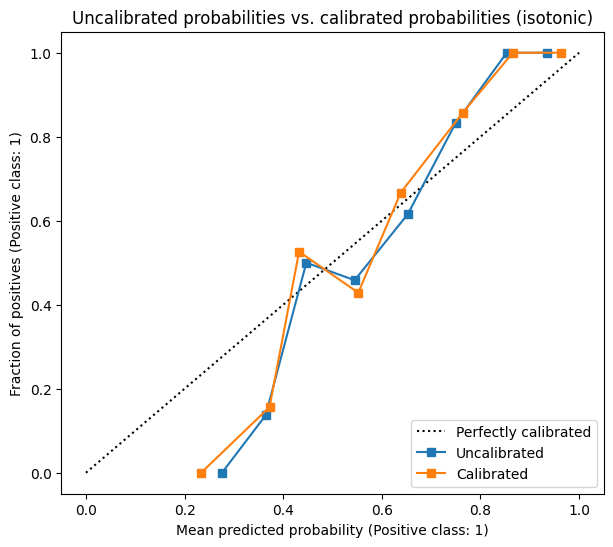

In [68]:
make_comparison_plot("isotonic", X_train, y_train, X_test, y_test, noise_pred_model)

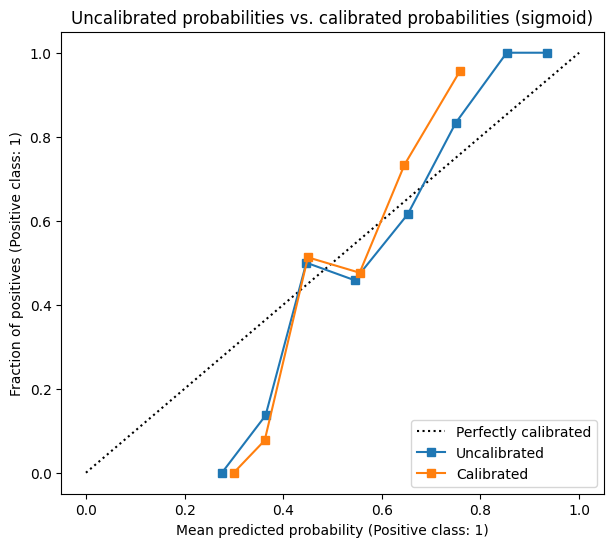

In [69]:
make_comparison_plot("sigmoid", X_train, y_train, X_test, y_test, noise_pred_model)

In [70]:
cal_clf = CalibratedClassifierCV(noise_pred_model, method="isotonic", n_jobs=-1)
cal_clf.fit(X_train, y_train)
reformatted["calibrated_proba"] = cal_clf.predict_proba(X)[:, 1]

In [72]:
preds["noise_proba"] = reformatted.groupby(["Subject"]).agg(
    {"calibrated_proba": "mean"}
)
preds["noise_preds"] = np.where(preds["noise_proba"] > 0.5, 1, 0)
preds_dict = preds["noise_preds"].to_dict()
preds_proba_dict = preds["noise_proba"].to_dict()
reformatted["agg_noise_proba"] = reformatted["Subject"].replace(preds_proba_dict)
reformatted["noise_preds"] = reformatted["Subject"].replace(preds_dict)

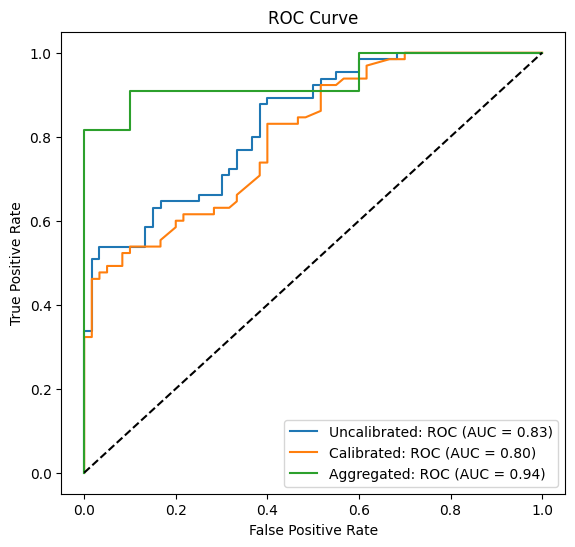

In [73]:
from sklearn import metrics

fig, ax = plt.subplots(figsize=(6.5, 6))
# Assuming y_test and y_pred_proba are defined
fpr_u, tpr_u, _ = metrics.roc_curve(
    y_test, noise_pred_model.predict_proba(X_test)[:, 1]
)
roc_auc_unc = metrics.auc(fpr_u, tpr_u)

fpr_c, tpr_c, _ = metrics.roc_curve(y_test, cal_clf.predict_proba(X_test)[:, 1])
roc_auc_cal = metrics.auc(fpr_c, tpr_c)


fpr_a, tpr_a, _ = metrics.roc_curve(
    y_test, reformatted["agg_noise_proba"][reformatted["DataGroup"] == "Test"]
)
roc_auc_agg = metrics.auc(fpr_a, tpr_a)

ax.plot(fpr_u, tpr_u, label=f"Uncalibrated: ROC (AUC = {roc_auc_unc:.2f})")
ax.plot(fpr_c, tpr_c, label=f"Calibrated: ROC (AUC = {roc_auc_cal:.2f})")
ax.plot(fpr_a, tpr_a, label=f"Aggregated: ROC (AUC = {roc_auc_agg:.2f})")
ax.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [74]:
(
    preds.values == reformatted.groupby(["Subject"]).agg({"target_90": "first"}).values
).sum() / len(preds)

0.9809523809523809

In [75]:
(reformatted["noise_preds"] == reformatted["target_90"]).mean()

0.9805194805194806

In [76]:
num_features = []
cat_features = ["noise_preds"]
log_features = ["Frequency(kHz)"]
for col in [
    "TotalVariance",
    "PeakILeftCurvature",
    "PeakIOverallCurvature",
    "PeakIRightCurvature",
    "TroughILeftCurvature",
    "TroughIOverallCurvature",
    "TroughIRightCurvature",
]:
    for i in [4, 5, 6, 7, 8]:
        cols = [c for c in reformatted.columns if c.startswith(f"{col}_{i}")]
        log_features.extend(cols)

for col in ["Amplitude", "Slope", "Distance"]:
    for i in [4, 5, 6, 7, 8]:
        cols = [c for c in reformatted.columns if c.startswith(f"{col}_{i}")]
        num_features.extend(cols)

concat_noise_pred_features = num_features + cat_features + log_features

X = reformatted[concat_noise_pred_features]
y = reformatted["SynapsesPerIHC"]

X_train, X_test, y_train, y_test = (
    X[reformatted.DataGroup != "Test"],
    X[reformatted.DataGroup == "Test"],
    y[reformatted.DataGroup != "Test"],
    y[reformatted.DataGroup == "Test"],
)

log_scale_pipeline = Pipeline(
    [
        ("log_transform", FunctionTransformer(np.log1p, validate=True)),
        ("scaler", StandardScaler()),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(drop="first", sparse_output=False), cat_features),
        ("log_transform", log_scale_pipeline, log_features),
    ]
)

In [77]:
rf_params = {
    "rf__n_estimators": [25, 50, 100, 150, 200, 30, 400, 500],
    "rf__max_depth": [5, 10, 20, 30, 40, 50, None],
    "rf__min_samples_leaf": [2, 5, 10, 15, 20, 30],
    "rf__min_samples_split": [2, 5, 10, 15, 20, 30],
    "rf__max_features": ["sqrt", "log2", 0.3, 0.5],
}

rf_pipeline = Pipeline(
    [("preprocessor", preprocessor), ("rf", RandomForestRegressor(random_state=1))]
)

# Use RandomizedSearchCV for efficiency
rf_search = RandomizedSearchCV(
    rf_pipeline,
    rf_params,
    cv=5,
    scoring="r2",
    random_state=1,
    n_jobs=-1,
)
rf_search.fit(X_train, y_train)
print(f"Best RF params: {rf_search.best_params_}")
r2 = rf_search.score(X_test, y_test)
print(f"Best RF score: {rf_search.best_score_:.3f}, R2 on test set: {r2:.3f}")
concat_noise_preds_model = rf_search.best_estimator_

Best RF params: {'rf__n_estimators': 30, 'rf__min_samples_split': 20, 'rf__min_samples_leaf': 2, 'rf__max_features': 0.5, 'rf__max_depth': None}
Best RF score: 0.367, R2 on test set: 0.615


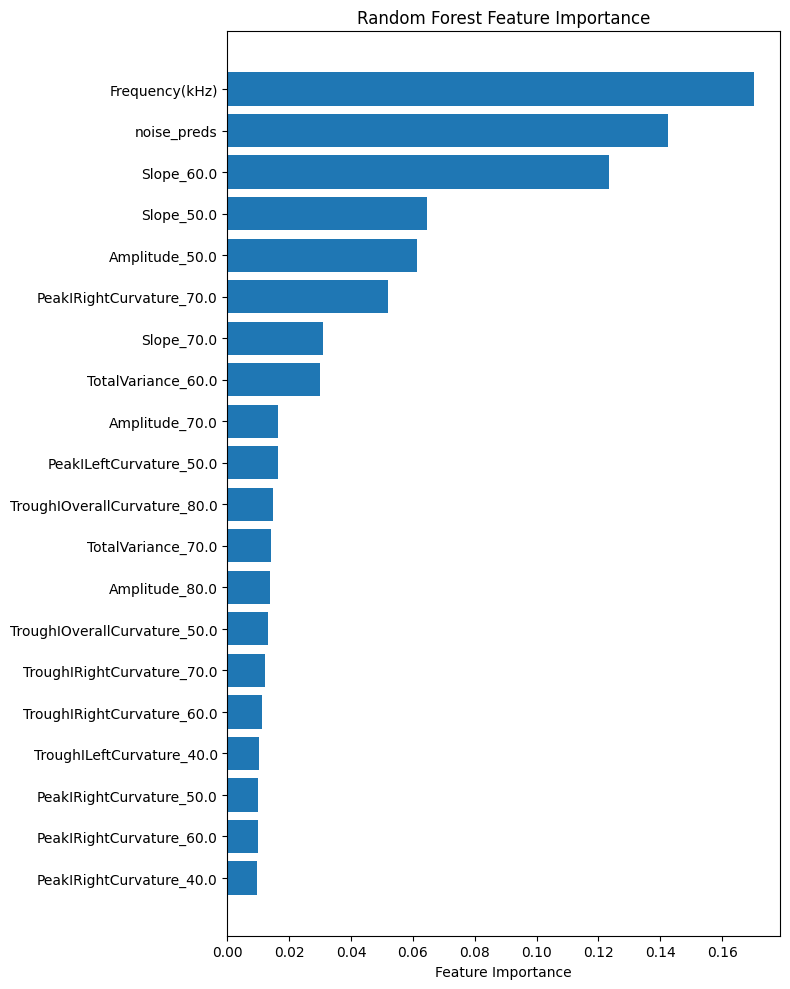

In [78]:
feature_importance = concat_noise_preds_model.named_steps["rf"].feature_importances_
feature_names = concat_noise_preds_model.feature_names_in_

importance_df = pd.DataFrame(
    {"Feature": feature_names, "Importance": feature_importance}
).sort_values("Importance", ascending=False)

plt.figure(figsize=(8, 10))
plt.barh(range(20), importance_df["Importance"][:20])
plt.yticks(range(20), importance_df["Feature"][:20])
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [79]:
def plot_results(x, y, alpha=0.5, markersize=5, title="", color=None):
    if color is None:
        color = np.random.rand(
            3,
        )
        while np.mean(color) > 0.6:
            color = np.random.rand(
                3,
            )
    plt.plot(x, y, "o", alpha=alpha, markersize=markersize, color=color)
    plt.plot([5, 20], [5, 20], "k--", alpha=0.5)
    plt.axis("square")
    plt.xticks(np.arange(5, 21, 5))
    plt.yticks(np.arange(5, 21, 5))
    plt.xlim(5, 20)
    plt.ylim(5, 20)
    plt.title(title)
    plt.xlabel("GT # Synapses")
    plt.ylabel("Predicted # Synapses")


def train_plot_result_frequency(df, rf_pipeline):
    freqs = sorted(X_train["Frequency(kHz)"].unique())
    plt.figure(figsize=(10, 4))

    color_palette = plt.cm.get_cmap("tab10", len(freqs) + 2)
    # iterate over dB levels:
    for i, frq in zip(range(len(freqs)), freqs):
        features = num_features + cat_features + log_features
        data = df[df["Frequency(kHz)"] == frq]
        X = data[features]
        y = data["SynapsesPerIHC"]
        X_train1, X_test1, y_train1, y_test1 = (
            X[data.DataGroup != "Test"],
            X[data.DataGroup == "Test"],
            y[data.DataGroup != "Test"],
            y[data.DataGroup == "Test"],
        )
        if len(X_train1) > 0 and len(X_test1) > 0:
            rf_pipeline.fit(X_train1, y_train1)
            r2 = rf_pipeline.score(X_test1, y_test1)
            rmse = np.sqrt(np.mean((y_test1 - rf_pipeline.predict(X_test1)) ** 2))
            print(f"{frq}Hz, {len(data)} samples, R2: {r2:.3f}, RMSE: {rmse:.3f}")
            plt.subplot(2, 4, i + 1)
            plot_results(
                y_test1,
                rf_pipeline.predict(X_test1),
                title=f"{frq}Hz",
                color=color_palette(i),
            )
            # show R2 in lower right corner of plot:
            plt.text(
                19.75,
                5,
                f"R2: {r2:.2f}",
                fontsize=10,
                horizontalalignment="right",
                verticalalignment="bottom",
            )

    # run on all data:
    rf_pipeline.fit(X_train, y_train)
    r2 = rf_pipeline.score(X_test, y_test)
    rmse = np.sqrt(np.mean((y_test - rf_pipeline.predict(X_test)) ** 2))
    print(f"All data, {len(df)} samples, R2: {r2:.3f}, RMSE: {rmse:.3f}")
    plt.subplot(2, 4, 7)
    plot_results(
        y_test,
        rf_pipeline.predict(X_test),
        alpha=0.25,
        title=f"All",
        color=color_palette(-2),
    )
    plt.text(
        19.75,
        5,
        f"R2: {r2:.2f}",
        fontsize=10,
        horizontalalignment="right",
        verticalalignment="bottom",
    )

    test_set = df[df["DataGroup"] == "Test"]
    test_set["RF predictions"] = rf_pipeline.predict(X_test)

    plt.text(
        19.75,
        5,
        f"R2: {r2:.2f}",
        fontsize=10,
        horizontalalignment="right",
        verticalalignment="bottom",
    )

    plt.tight_layout()
    plt.show()

8.0Hz, 102 samples, R2: 0.018, RMSE: 1.005
11.3Hz, 103 samples, R2: -0.071, RMSE: 1.166
16.0Hz, 103 samples, R2: -0.027, RMSE: 1.284
22.6Hz, 103 samples, R2: 0.755, RMSE: 2.038
32.0Hz, 105 samples, R2: 0.498, RMSE: 3.207
45.2Hz, 100 samples, R2: 0.522, RMSE: 3.173
All data, 616 samples, R2: 0.615, RMSE: 2.184


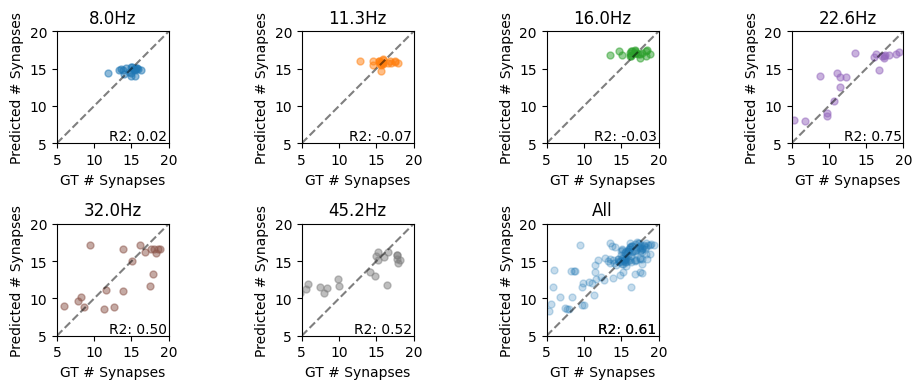

In [80]:
train_plot_result_frequency(reformatted, concat_noise_preds_model)

In [81]:
num_features = []
cat_features = ["noise_preds"]
log_features = ["Frequency(kHz)"]
for col in [
    "TotalVariance",
    "PeakILeftCurvature",
    "PeakIOverallCurvature",
    "PeakIRightCurvature",
    "TroughILeftCurvature",
    "TroughIOverallCurvature",
    "TroughIRightCurvature",
]:
    for i in [4, 5, 6, 7, 8]:
        cols = [c for c in reformatted.columns if c.startswith(f"{col}_{i}")]
        log_features.extend(cols)

for col in ["Amplitude", "Slope", "Distance"]:
    for i in [4, 5, 6, 7, 8]:
        cols = [c for c in reformatted.columns if c.startswith(f"{col}_{i}")]
        num_features.extend(cols)

X = reformatted[concat_noise_pred_features]
y = reformatted["SynapsesPerIHC"]

X_train, X_test, y_train, y_test = (
    X[reformatted.DataGroup != "Test"],
    X[reformatted.DataGroup == "Test"],
    y[reformatted.DataGroup != "Test"],
    y[reformatted.DataGroup == "Test"],
)

log_scale_pipeline = Pipeline(
    [
        ("log_transform", FunctionTransformer(np.log1p, validate=True)),
        ("scaler", StandardScaler()),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(drop="first", sparse_output=False), cat_features),
        ("log_transform", log_scale_pipeline, log_features),
    ]
)

In [82]:
import multiprocessing
import xgboost as xgb

clf_params = {
    "clf__n_estimators": [25, 30, 50, 100, 150, 200, 300, 500],
    "clf__max_depth": [2, 4, 6, 8, 10],
}

clf_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "clf",
            xgb.XGBRegressor(
                tree_method="hist",
                n_jobs=multiprocessing.cpu_count() // 2,
            ),
        ),
    ]
)

# Use RandomizedSearchCV for efficiency
clf_search = GridSearchCV(
    clf_pipeline,
    clf_params,
    cv=5,
    scoring="r2",
    n_jobs=2,
)
clf_search.fit(X_train, y_train)
print(f"Best RF params: {clf_search.best_params_}")
r2 = clf_search.score(X_test, y_test)
print(f"Best RF score: {clf_search.best_score_:.3f}, R2 on test set: {r2:.3f}")
concat_noise_pred_xgb_model = clf_search.best_estimator_

Best RF params: {'clf__max_depth': 2, 'clf__n_estimators': 25}
Best RF score: 0.326, R2 on test set: 0.646


8.0Hz, 102 samples, R2: -0.073, RMSE: 1.050
11.3Hz, 103 samples, R2: -0.237, RMSE: 1.254
16.0Hz, 103 samples, R2: -0.144, RMSE: 1.355
22.6Hz, 103 samples, R2: 0.766, RMSE: 1.990
32.0Hz, 105 samples, R2: 0.527, RMSE: 3.115
45.2Hz, 100 samples, R2: 0.479, RMSE: 3.312
All data, 616 samples, R2: 0.646, RMSE: 2.093


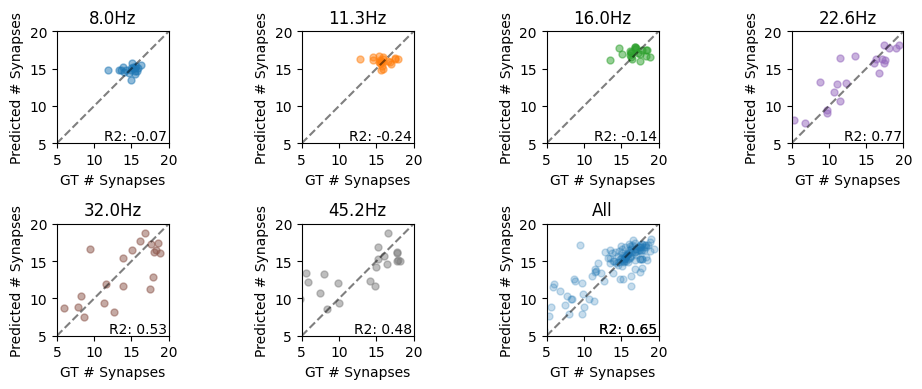

In [83]:
train_plot_result_frequency(reformatted, concat_noise_pred_xgb_model)

In [84]:
num_features = ["Noise"]
cat_features = []
log_features = ["Frequency(kHz)"]
for col in [
    "TotalVariance",
    "PeakILeftCurvature",
    "PeakIOverallCurvature",
    "PeakIRightCurvature",
    "TroughILeftCurvature",
    "TroughIOverallCurvature",
    "TroughIRightCurvature",
]:
    for i in [4, 5, 6, 7, 8]:
        cols = [c for c in reformatted.columns if c.startswith(f"{col}_{i}")]
        log_features.extend(cols)

for col in ["Amplitude", "Slope", "Distance"]:
    for i in [4, 5, 6, 7, 8]:
        cols = [c for c in reformatted.columns if c.startswith(f"{col}_{i}")]
        num_features.extend(cols)
concat_noise_features = num_features + cat_features + log_features

X = reformatted[concat_noise_features]
y = reformatted["SynapsesPerIHC"]

X_train, X_test, y_train, y_test = (
    X[reformatted.DataGroup != "Test"],
    X[reformatted.DataGroup == "Test"],
    y[reformatted.DataGroup != "Test"],
    y[reformatted.DataGroup == "Test"],
)

log_scale_pipeline = Pipeline(
    [
        ("log_transform", FunctionTransformer(np.log1p, validate=True)),
        ("scaler", StandardScaler()),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(drop="first", sparse_output=False), cat_features),
        ("log_transform", log_scale_pipeline, log_features),
    ]
)

In [85]:
rf_params = {
    "rf__n_estimators": [25, 50, 100, 150, 200, 30, 400, 500],
    "rf__max_depth": [5, 10, 20, 30, 40, 50, None],
    "rf__min_samples_leaf": [2, 5, 10, 15, 20, 30],
    "rf__min_samples_split": [2, 5, 10, 15, 20, 30],
    "rf__max_features": ["sqrt", "log2", 0.3, 0.5],
}

rf_pipeline = Pipeline(
    [("preprocessor", preprocessor), ("rf", RandomForestRegressor(random_state=1))]
)

# Use RandomizedSearchCV for efficiency
rf_search = RandomizedSearchCV(
    rf_pipeline,
    rf_params,
    cv=5,
    scoring="r2",
    random_state=1,
    n_jobs=-1,
)
rf_search.fit(X_train, y_train)
print(f"Best RF params: {rf_search.best_params_}")
r2 = rf_search.score(X_test, y_test)
print(f"Best RF score: {rf_search.best_score_:.3f}, R2 on test set: {r2:.3f}")
concat_noise_rf_model = rf_search.best_estimator_

Best RF params: {'rf__n_estimators': 30, 'rf__min_samples_split': 20, 'rf__min_samples_leaf': 2, 'rf__max_features': 0.5, 'rf__max_depth': None}
Best RF score: 0.388, R2 on test set: 0.690


8.0Hz, 102 samples, R2: 0.048, RMSE: 0.989
11.3Hz, 103 samples, R2: -0.106, RMSE: 1.185
16.0Hz, 103 samples, R2: -0.043, RMSE: 1.294
22.6Hz, 103 samples, R2: 0.728, RMSE: 2.145
32.0Hz, 105 samples, R2: 0.584, RMSE: 2.921
45.2Hz, 100 samples, R2: 0.754, RMSE: 2.278
All data, 616 samples, R2: 0.690, RMSE: 1.960


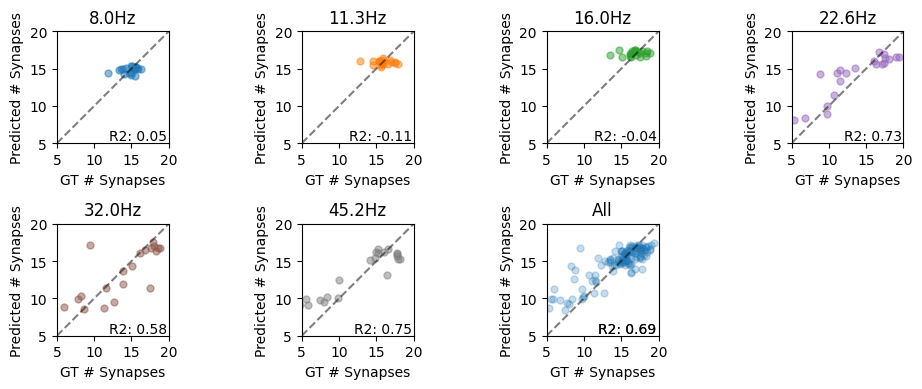

In [86]:
train_plot_result_frequency(reformatted, concat_noise_rf_model)

In [87]:
clf_params = {
    "clf__n_estimators": [25, 30, 50, 100, 150, 200, 300, 500],
    "clf__max_depth": [2, 4, 6, 8, 10],
}

clf_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "clf",
            xgb.XGBRegressor(
                tree_method="hist",
                n_jobs=multiprocessing.cpu_count() // 2,
            ),
        ),
    ]
)

# Use RandomizedSearchCV for efficiency
clf_search = GridSearchCV(
    clf_pipeline,
    clf_params,
    cv=5,
    scoring="r2",
    n_jobs=2,
)
clf_search.fit(X_train, y_train)
print(f"Best RF params: {clf_search.best_params_}")
r2 = clf_search.score(X_test, y_test)
print(f"Best RF score: {clf_search.best_score_:.3f}, R2 on test set: {r2:.3f}")
concat_noise_xgb_model = clf_search.best_estimator_

Best RF params: {'clf__max_depth': 2, 'clf__n_estimators': 25}
Best RF score: 0.399, R2 on test set: 0.694


8.0Hz, 102 samples, R2: -0.142, RMSE: 1.083
11.3Hz, 103 samples, R2: -0.237, RMSE: 1.254
16.0Hz, 103 samples, R2: -0.218, RMSE: 1.398
22.6Hz, 103 samples, R2: 0.867, RMSE: 1.498
32.0Hz, 105 samples, R2: 0.574, RMSE: 2.953
45.2Hz, 100 samples, R2: 0.873, RMSE: 1.634
All data, 616 samples, R2: 0.694, RMSE: 1.945


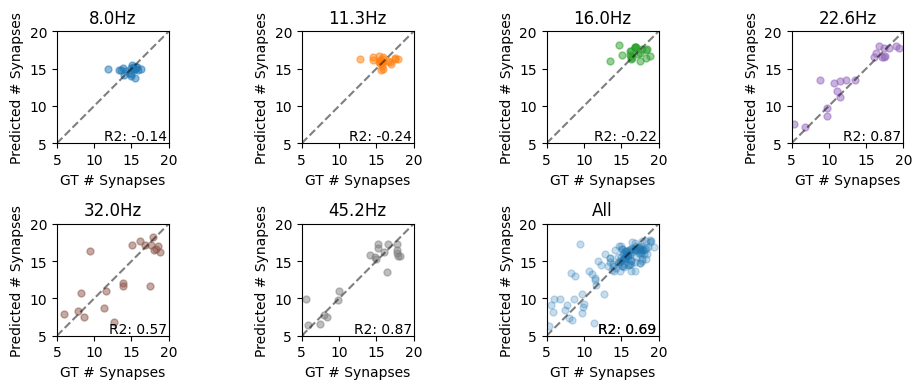

In [88]:
train_plot_result_frequency(reformatted, concat_noise_xgb_model)